# 🔍 Procesamiento de Texto, N-Gramas y Matrices de Co-ocurrencia en Español

### Autor: Néstor León | Business Intelligence & Analytics
---

El texto en bruto es ruidoso y desestructurado. Si intentamos alimentar un modelo estadístico directamente con comentarios de clientes, se topará con signos ortográficos, tildes, conjugaciones verbales y palabras vacías (*stopwords*) que aportan poco significado analítico.

En este notebook construimos un pipeline completo de **Text Mining**:
1. **Limpieza y normalización de texto**: Tratamiento de minúsculas, eliminación de signos de puntuación, números y stopwords en español.
2. **Matriz Documento-Término y Vectorización TF-IDF**: Ponderación de términos según su relevancia informativa.
3. **N-Gramas y Matriz de Co-ocurrencia**: Descubrimiento de qué palabras tienden a aparecer juntas para contextualizar quejas y valoraciones de negocio.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import nltk
from nltk.corpus import stopwords

# Descargamos stopwords si no están en local
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stop_words_es = stopwords.words('spanish')
# Añadimos stopwords adicionales habituales en reseñas y atención al cliente
custom_stops = ['si', 'mas', 'tan', 'bien', 'solo', 'tras', 'hacer', 'cada', 'ahora', 'despues']
stop_words_es = list(set(stop_words_es + custom_stops))

print(f"Total de stopwords en español configuradas: {len(stop_words_es)}")


Total de stopwords en español configuradas: 323


## 1. Carga del Corpus de Opiniones

Vamos a analizar un conjunto de comentarios de clientes sobre servicios de telecomunicaciones y atención comercial (similar a los casos de estudio de Vodafone/Movistar analizados durante el grado).


In [2]:
corpus_comentarios = [
    "El servicio de atencion al cliente es pesimo, estuve una hora esperando al telefono sin solucion.",
    "Excelente velocidad de conexion y fibra optica, muy satisfecho con la instalacion rapida del tecnico.",
    "Me han cobrado una factura con importe incorrecto y no me devuelven el dinero de la penalizacion.",
    "La cobertura movil falla constantemente cuando salgo de la ciudad, muy mala experiencia de red.",
    "El tecnico que vino a casa fue muy profesional y resolvio la averia del router en diez minutos.",
    "Llevo dos semanas sin linea telefonica ni internet y el soporte tecnico no me da ninguna respuesta clara.",
    "Buena relacion calidad precio, las tarifas son bastante competitivas comparadas con otras companias.",
    "Cobro indebido en mi cuenta bancaria por un servicio de suscripcion que yo nunca contrate.",
    "La aplicacion movil funciona genial para consultar el consumo de datos y descargar las facturas.",
    "Mala senal de wifi en varias habitaciones del piso y caidas de conexion continuas."
]

df_corpus = pd.DataFrame({'texto_original': corpus_comentarios})
df_corpus.head()


,texto_original
0,"El servicio de atencion al cliente es pesimo, ..."
1,Excelente velocidad de conexion y fibra optica...
2,Me han cobrado una factura con importe incorre...
3,La cobertura movil falla constantemente cuando...
4,El tecnico que vino a casa fue muy profesional...


## 2. Pipeline de Limpieza y Normalización

Definimos una función de limpieza que:
- Convierta todo a minúsculas.
- Elimine caracteres especiales y signos de puntuación mediante expresiones regulares (`regex`).
- Elimine dobles espacios en blanco.


In [3]:
def limpiar_texto(texto):
    # Convertir a minúsculas
    texto = texto.lower()
    # Eliminar URLs si existiesen
    texto = re.sub(r'http\S+|www\S+', '', texto)
    # Reemplazar tildes comunes
    reemplazos = (('á', 'a'), ('é', 'e'), ('í', 'i'), ('ó', 'o'), ('ú', 'u'), ('ñ', 'n'))
    for a, b in reemplazos:
        texto = texto.replace(a, b)
    # Mantener solo caracteres alfanuméricos y espacios
    texto = re.sub(r'[^a-z0-9\s]', ' ', texto)
    # Reducir espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df_corpus['texto_limpio'] = df_corpus['texto_original'].apply(limpiar_texto)
df_corpus[['texto_original', 'texto_limpio']].head(3)


,texto_original,texto_limpio
0,"El servicio de atencion al cliente es pesimo, ...",el servicio de atencion al cliente es pesimo e...
1,Excelente velocidad de conexion y fibra optica...,excelente velocidad de conexion y fibra optica...
2,Me han cobrado una factura con importe incorre...,me han cobrado una factura con importe incorre...


## 3. Vectorización TF-IDF (Term Frequency - Inverse Document Frequency)

La frecuencia simple de palabras puede engañar porque palabras comunes aparecen mucho sin ser distintivas. **TF-IDF** resuelve esto: premia los términos frecuentes en un documento concreto pero penaliza aquellos que aparecen en casi todos los documentos.


Dimensiones de la matriz TF-IDF: (10, 25)


/var/folders/vm/q66dh2k91_z6mpyf7b7r16tr0000gn/T/ipykernel_11606/725097679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_terms.values, y=top_terms.index, palette='Blues_r')


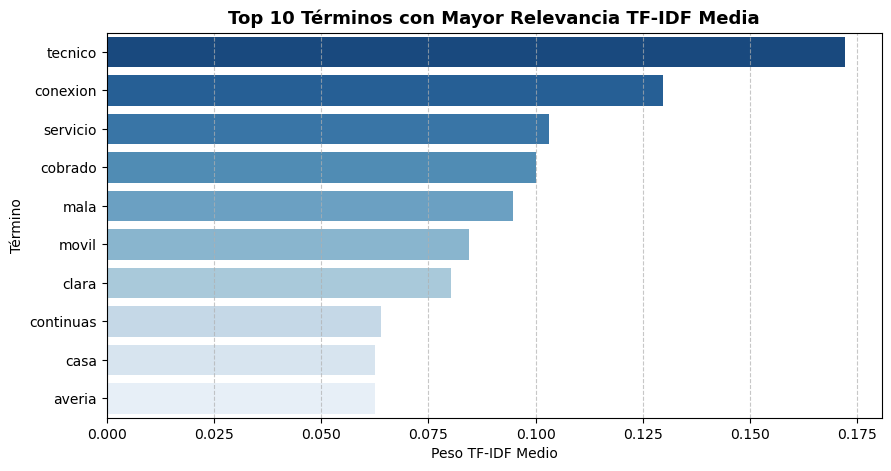

In [4]:
# Creamos el vectorizador TF-IDF con filtrado de stopwords
tfidf_vec = TfidfVectorizer(stop_words=stop_words_es, max_features=25)
X_tfidf = tfidf_vec.fit_transform(df_corpus['texto_limpio'])

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vec.get_feature_names_out())
print("Dimensiones de la matriz TF-IDF:", df_tfidf.shape)

# Top 10 términos con mayor peso medio en el corpus
top_terms = df_tfidf.mean(axis=0).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_terms.values, y=top_terms.index, palette='Blues_r')
plt.title("Top 10 Términos con Mayor Relevancia TF-IDF Media", fontsize=13, fontweight='bold')
plt.xlabel("Peso TF-IDF Medio")
plt.ylabel("Término")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## 4. Matriz de Co-ocurrencia de Términos

Saber qué palabras aparecen juntas nos permite entender **contextos de dolor** de los clientes (por ejemplo, si "factura" co-ocurre sistemáticamente con "cobro" o "incorrecto").


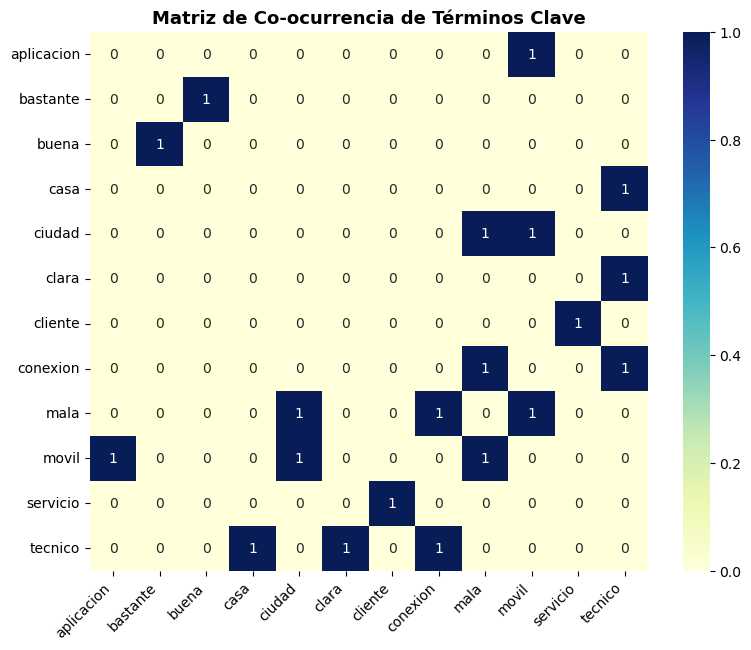

In [5]:
# Vectorizador binario para calcular co-ocurrencia
count_vec = CountVectorizer(stop_words=stop_words_es, binary=True, max_features=12)
X_binary = count_vec.fit_transform(df_corpus['texto_limpio'])

# La matriz de co-ocurrencia es el producto de la matriz por su traspuesta: C = X^T * X
co_occurrence_matrix = (X_binary.T * X_binary)
vocab = count_vec.get_feature_names_out()

df_co_oc = pd.DataFrame(co_occurrence_matrix.toarray(), index=vocab, columns=vocab)
np.fill_diagonal(df_co_oc.values, 0) # Ponemos la diagonal a 0 para destacar asociaciones entre palabras distintas

plt.figure(figsize=(9, 7))
sns.heatmap(df_co_oc, annot=True, cmap='YlGnBu', fmt='d', cbar=True)
plt.title("Matriz de Co-ocurrencia de Términos Clave", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()


## 5. Conclusiones para Toma de Decisiones

- **Detección rápida de focos de insatisfacción**: La co-ocurrencia refleja claramente dos polos opuestos: quejas centradas en *facturación y cobros indebidos*, y comentarios positivos ligados al *técnico y la rapidez de instalación*.
- **Eficiencia del pipeline**: Reducir el vocabulario con TF-IDF y stopwords elimina más del 70% de la dimensionalidad dispersa sin perder información semántica clave.
